In [1]:
from neurovlm.data import fetch_data, load_latent
from neurovlm import NeuroVLM

# Fetch models and datasets
fetch_data()

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Fetching 26 files:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching 26 files:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

...

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Data fetch complete. Cache directory: /home/rph/.cache/huggingface/hub


'/home/rph/.cache/huggingface/hub'

# Quickstart

This tutorial introduces the high-level, inference-only API. It walks through text-to-brain and brain-to-text generation and retrieval.

## Generative models

### Text-to-Brain: Generative

The default text-to-brain model is from the PubMed training set, thus inherits biases of that set. For example, anatomy is not always well followed and probabilities are not calibrated. However, this is a base model that can be fined-tuned and calibrated. A calibrator class if provided in:

`from neurovlm.adapter import LogitCalibrator`

A anatomy-focused fine-tune adapter of the base model is provided, along with a learned calibrator. To use this model, set `.to_brain(head='mse', adapter=True)`. Custom adapters should be trained per use-case.

In [2]:
# Initialize with CPU device explicitly
# On Mac, avoid device conflicts by using CPU
nvlm = NeuroVLM(device="cpu")
result = nvlm.text(["vision", "default mode network"]).to_brain(head="mse")
result.to_nifti() # returns list of nib.Nifti1Image

There are adapters available but none are activated for the forward pass.


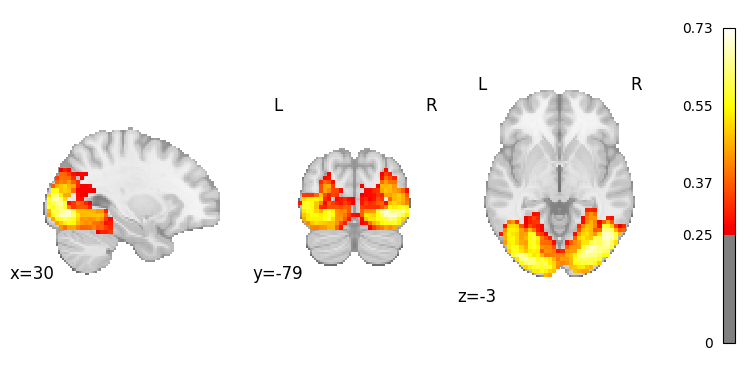

In [3]:
result.plot(0, threshold=0.25); # plot image for vision

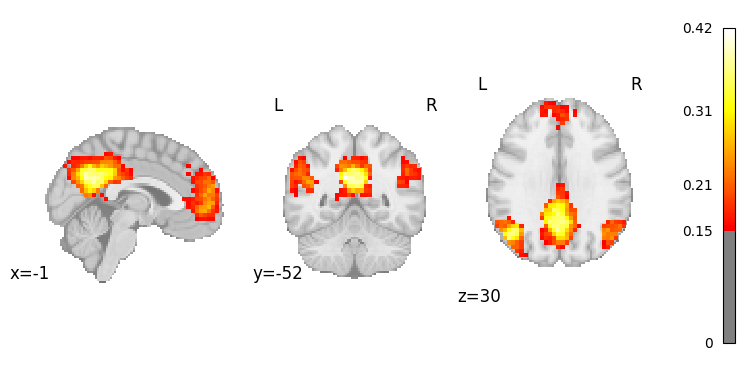

In [4]:
result.plot(1, threshold=0.15); # plot image for DMN

Use the anatomy adapter + calibrator head

In [5]:
result = nvlm.text(["insula", "putamen"]).to_brain(head="mse", adapter=True)

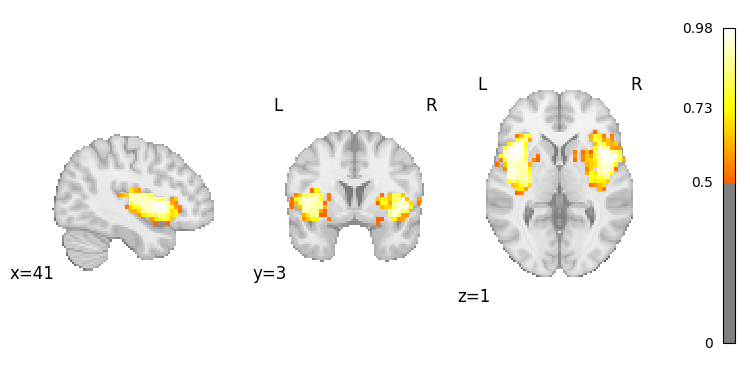

In [6]:
result.plot(0, threshold=0.5); # plot image for insula

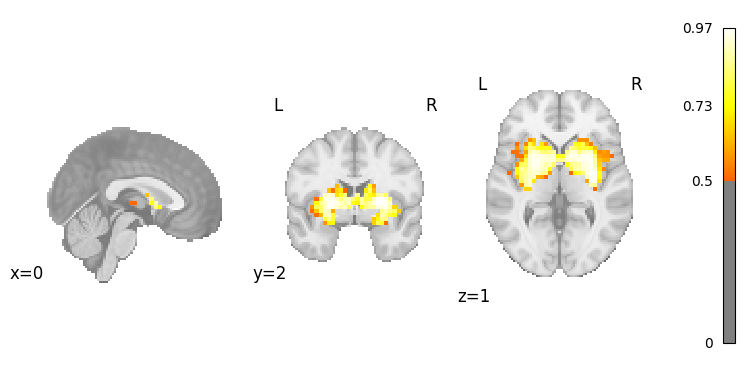

In [7]:
result.plot(1, threshold=0.5); # plot image for putamen

## Brain-to-text: Generative

In [8]:
nvlm = NeuroVLM(device="cuda")
networks = load_latent("networks_neuro")
result = nvlm.brain([networks["Du"]["AUD"], networks["Du"]["DN-A"]]).to_text()

In [9]:
# Text generated from the AUD map
print(result[0])

[NETWORK]Auditory Network
The auditory network is broadly distributed across the superior temporal gyrus, central sulcus, inferior frontal gyrus, and adjacent regions. It is broadly associated with the processing of sound features such as pitch, duration, and timbre. The network is often described as a central hub for auditory perception. It is thought to support the organization of sound into meaningful auditory experiences.


In [10]:
# Text generated from the DN-A map
print(result[1])

[NETWORK]Default Mode Network
The default mode network includes medial prefrontal cortex, posterior cingulate cortex, angular gyrus, inferior parietal lobule, precuneus, and temporoparietal junction. It is commonly associated with self-referential thought, memory retrieval, and social cognition.


## Contrastive models

### Text-to-Brain: Contrastive Ranking & Retrieval

Contrastive models are used for ranking and retrieval. We can lookup similar neuroimages in a dataset, given a text query. This works by embedding the text query and comparing a set of image embeddings via cosine similarity.

In [11]:
# Initialize with CPU device explicitly
nvlm = NeuroVLM(device="cpu")
result = nvlm.text("motor").to_brain(head='infonce')
top = result.top_k(2) # each row pairs to a neuorimage that is most similar to the text query
top

There are adapters available but none are activated for the forward pass.


,dataset,dataset_index,title,description,cosine_similarity
0,networks,82,Shirer,Sensorimotor,0.438795
1,networks,130,WashU,Effector-hand,0.432333
2,neurovault,1939,Brain responses to anticipatory cues and milks...,There is substantial variability in percent to...,0.463300
3,neurovault,1068,Large-Scale Network Coupling with the Fusiform...,"Large-scale functional networks, as identified...",0.449919
4,pubmed,6401,Group-level variations in motor representation...,Navigated transcranial magnetic stimulation (T...,0.466430
5,pubmed,904,Ipsilateral motor cortex activation on functio...,"Distal, unilateral hand movements can be assoc...",0.459416


Each row in the `top` dataframe above, is paried to an image that can be viewed.

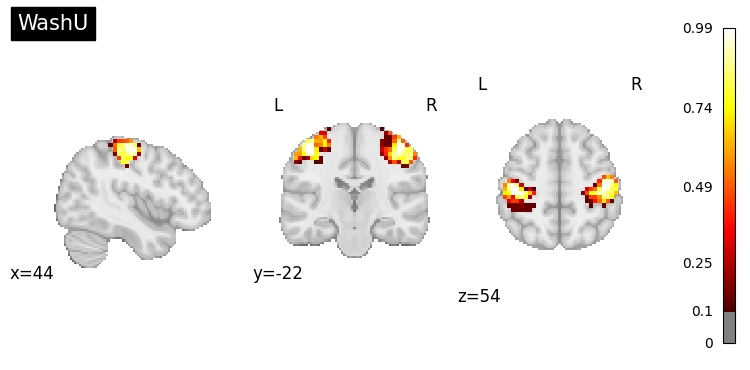

In [12]:
# WashU network atlas
top.plot_row(1, threshold=0.1);

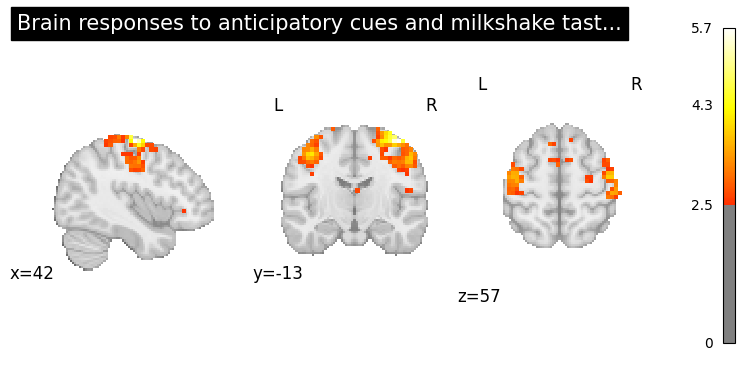

In [13]:
# NeuroVault
top.plot_row(2, threshold=2.5);

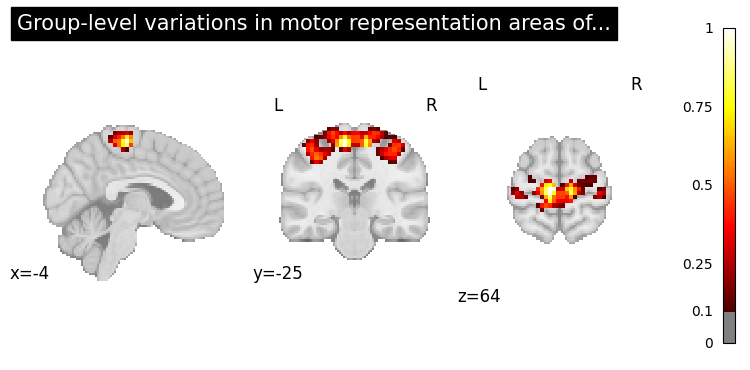

In [14]:
# PubMed
top.plot_row(4, threshold=0.1);

### Brain-to-Text: Contrastive Ranking & Retrieval

Here we use an auditory map as input from the Du atlas. We use the contrastive model to rank the most similar text across the datasets.

In [15]:
# Transform rank text based on auditory network
nvlm = NeuroVLM(device="cpu")
result = nvlm.brain(networks["Du"]["AUD"]).to_text(head='infonce')

In [16]:
result.top_k(5, dataset="pubmed")

,dataset,title,description,cosine_similarity
0,pubmed,The processing of temporal pitch and melody in...,An fMRI experiment was performed to identify t...,0.526884
1,pubmed,"Heschl's gyrus, posterior superior temporal gy...",A part of the auditory system automatically de...,0.504547
2,pubmed,Hierarchical processing of sound location and ...,Horizontal sound localization relies on the ex...,0.499913
3,pubmed,Brain bases for auditory stimulus-driven figur...,"Auditory figure-ground segregation, listeners'...",0.490401
4,pubmed,Dichotic pitch activates pitch processing cent...,Although several neuroimaging studies have rep...,0.485120


In [17]:
result.top_k(5, dataset="pubmed_mesh")

,dataset,title,description,cosine_similarity
0,pubmed_mesh,auditory cortex,The Auditory Cortex is a region of the brain l...,0.424034
1,pubmed_mesh,human auditory cortex,The human auditory cortex is a specialized reg...,0.420337
2,pubmed_mesh,"recruitment detection, audiologic","Recruitment Detection, Audiologic refers to a ...",0.419473
3,pubmed_mesh,superior temporal regions,The superior temporal regions are part of the ...,0.417734
4,pubmed_mesh,secondary auditory cortex,The secondary auditory cortex is a region of t...,0.416860


In [18]:
result.top_k(5, dataset='llm_neuro_terms')

,dataset,title,description,cosine_similarity
0,llm_neuro_terms,acoustic processing hierarchy,a hierarchical organization of brain regions i...,0.461465
1,llm_neuro_terms,auditory attention,the process of focusing on auditory information.,0.461102
2,llm_neuro_terms,auditory area,brain regions responsible for processing sound...,0.459281
3,llm_neuro_terms,pitch processing,Pitch processing is a neuroscience term used a...,0.446591
4,llm_neuro_terms,auditory processing,the process of interpreting auditory stimuli.,0.445352


In [19]:
result.top_k(5, dataset='cogatlas')

,dataset,title,description,cosine_similarity
0,cogatlas,auditory stream segregation,The perceptual grouping of sounds to form cohe...,0.437669
1,cogatlas,auditory encoding,The process of storing auditory information in...,0.431347
2,cogatlas,music cognition,The processing of mental functions on auditory...,0.431245
3,cogatlas,acoustic phonetic processing,The cognitive ability to discriminate items on...,0.423635
4,cogatlas,auditory tone detection,Determining the presence of an auditory stimul...,0.417665


In [20]:
result.top_k(5, dataset='wiki')

,dataset,title,description,cosine_similarity
0,wiki,Temporal masking,Temporal masking or non-simultaneous masking o...,0.489581
1,wiki,Melodic expectation,"In music cognition and musical analysis, the s...",0.454363
2,wiki,Search by sound,Search by sound is the retrieval of informatio...,0.452222
3,wiki,Beat (acoustics),"In acoustics, a beat is an interference patter...",0.447247
4,wiki,Harmonic series (music),The harmonic series (also overtone series) is ...,0.446160
